In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'segmentation-models-pytorch==0.5.0', 'grad-cam==1.5.5',
                'ImageHash==4.3.2', 'py7zr>=0.22,<1', 'scikit-learn>=1.5,<2',
                'matplotlib', 'pandas', 'tqdm', 'Pillow'], check=True)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import os, sys, subprocess, json, hashlib, random, time, gc, zipfile, shutil, platform
import py7zr
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
import imagehash
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import segmentation_models_pytorch as smp

ROOT = Path('/content/drive/MyDrive/RiceLeaf')
RUN_NAME = 'experiment_v1'
RUN = ROOT / 'runs' / RUN_NAME
LOCAL = Path('/content/riceleaf_v2_data')
DATA_DIR = ROOT / 'data'

def detect_archives(data_dir):
    archives = None
    last_error = None
    for attempt in range(6):
        try:
            folder_exists = data_dir.is_dir()
            if not folder_exists:
                raise FileNotFoundError(f'Folder does not exist: {data_dir}')
            archives = [p for p in data_dir.iterdir()
                        if p.is_file() and p.suffix.lower() in {'.zip','.7z'}]
            break
        except FileNotFoundError:
            raise
        except (ConnectionAbortedError, ConnectionResetError, OSError) as error:
            last_error = error
            print(f'Google Drive access failed ({attempt + 1}/6): {error}')
            time.sleep(3)
    if archives is None:
        raise ConnectionError(
            'Google Drive disconnected. Remount Drive, '
            'then rerun this configuration cell.'
        ) from last_error
    image_candidates = [p for p in archives if 'mask' not in p.name.lower() and 'segment' not in p.name.lower()]
    mask_candidates = [p for p in archives if 'mask' in p.name.lower() or 'segment' in p.name.lower()]
    if len(image_candidates) != 1 or len(mask_candidates) != 1:
        listing = '\n'.join(f'- {p.name}' for p in archives) or '(no ZIP/7z archives)'
        raise FileNotFoundError(
            'The notebook must find exactly one image archive and one mask archive in '
            f'{data_dir}. File terdeteksi:\n{listing}'
        )
    return image_candidates[0], mask_candidates[0]

IMAGE_ZIP, MASK_ZIP = detect_archives(DATA_DIR)
CANDIDATES = ['densenet121', 'convnext_tiny', 'efficientnet_v2_s']
IMAGE_SIZE = 320
BATCH_SIZE = 8
ACCUMULATION = 2
EPOCHS = 30
PATIENCE = 7
SEG_EPOCHS = 30
TRAIN_SEGMENTATION = True
MASK_WHITE_IS_LESION = True  # change after auditing if black pixels represent disease
SEED = 42
NUM_WORKERS = 2
PHASH_DISTANCE = 4
CLASSES = ['bacterial_blight', 'blast', 'brown_spot', 'tungro']
LABELS = ['Bacterial Blight', 'Blast', 'Brown Spot', 'Tungro']
for folder in [RUN, LOCAL]:
    folder.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print(torch.cuda.get_device_name(0))
else:
    raise RuntimeError('Select a GPU in Runtime settings before training. Torch will not be reinstalled.')
def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
CONFIG = dict(classes=CLASSES, candidates=CANDIDATES, image_size=IMAGE_SIZE,
              batch_size=BATCH_SIZE, accumulation=ACCUMULATION, epochs=EPOCHS,
              patience=PATIENCE, seg_epochs=SEG_EPOCHS, seed=SEED,
              phash_distance=PHASH_DISTANCE, mask_white=MASK_WHITE_IS_LESION,
              train_segmentation=TRAIN_SEGMENTATION, pipeline_version=1)
config_file = RUN / 'config.json'
if config_file.exists():
    assert json.loads(config_file.read_text()) == CONFIG, 'Configuration changed: use a new RUN_NAME.'
else:
    config_file.write_text(json.dumps(CONFIG, indent=2))
(RUN / 'requirements_observed.txt').write_text(subprocess.check_output(
    [sys.executable, '-m', 'pip', 'freeze'], text=True))
print('PyTorch:', torch.__version__, '| Torchvision:', torchvision.__version__)
print('Image archive:', IMAGE_ZIP.name)
print('Mask archive :', MASK_ZIP.name)
print('Output:', RUN)


In [ ]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

def unpack(archive, target):
    if not archive.is_file():
        raise FileNotFoundError(f'Place the official source archive in {archive}')
    digest = sha256(archive)
    marker = target / '.complete.json'
    if marker.exists():
        assert json.loads(marker.read_text())['sha256'] == digest, 'Archive changed; use a new LOCAL directory.'
        return digest
    target.mkdir(parents=True, exist_ok=True)
    def extract_one(zpath, dest):
        dest.mkdir(parents=True, exist_ok=True)
        if zpath.suffix.lower() == '.zip':
            with zipfile.ZipFile(zpath) as z:
                for info in z.infolist():
                    resolved = (dest / info.filename).resolve()
                    assert resolved.is_relative_to(dest.resolve()), 'Unsafe ZIP path.'
                    assert ((info.external_attr >> 16) & 0o170000) != 0o120000, 'ZIP symlinks are not allowed.'
                z.extractall(dest)
        elif zpath.suffix.lower() == '.7z':
            with py7zr.SevenZipFile(zpath, mode='r') as z:
                for name in z.getnames():
                    resolved = (dest / name).resolve()
                    assert resolved.is_relative_to(dest.resolve()), 'Unsafe 7z path.'
                z.extractall(dest)
        else:
            raise ValueError(f'Unsupported archive format: {zpath.suffix}')
    extract_one(archive, target)
    seen = set()
    for depth in range(5):
        nested = [p for p in target.rglob('*.zip') if str(p) not in seen]
        if not nested:
            break
        for p in nested:
            seen.add(str(p)); extract_one(p, p.parent / (p.stem + '_unpacked'))
    marker.write_text(json.dumps({'sha256': digest}))
    return digest

image_digest = unpack(IMAGE_ZIP, LOCAL / 'images')
mask_digest = unpack(MASK_ZIP, LOCAL / 'masks') if TRAIN_SEGMENTATION else None
dataset_identity = dict(images=image_digest, masks=mask_digest)
identity_file = RUN / 'dataset_identity.json'
if identity_file.exists():
    assert json.loads(identity_file.read_text()) == dataset_identity, 'Dataset changed: use a new RUN_NAME.'
else:
    identity_file.write_text(json.dumps(dataset_identity, indent=2))
print('Archives extracted; dataset identity recorded.')


In [ ]:
def canonical(text):
    return ''.join(c for c in text.lower() if c.isalnum())
ALIASES = {'bacterialblight':'bacterial_blight', 'bacteriablight':'bacterial_blight',
           'bacterialleafblight':'bacterial_blight', 'blast':'blast',
           'leafblast':'blast', 'brownspot':'brown_spot', 'tungro':'tungro'}
def folder_label(path):
    for part in reversed(path.parent.parts):
        if canonical(part) in ALIASES:
            return ALIASES[canonical(part)]
    return None
def read_rgb(path):
    with Image.open(path) as im:
        return ImageOps.exif_transpose(im).convert('RGB')
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
rows, bad = [], []
for path in tqdm(sorted((LOCAL / 'images').rglob('*')), desc='Image audit'):
    if path.suffix.lower() not in EXTENSIONS or '__MACOSX' in path.parts:
        continue
    label = folder_label(path)
    if label is None:
        bad.append({'path':str(path), 'error':'unrecognized class folder'}); continue
    try:
        im = read_rgb(path)
        pixel_hash = hashlib.sha256(str(im.size).encode() + im.tobytes()).hexdigest()
        rows.append(dict(path=str(path), label=label, filename=path.name,
                         width=im.width, height=im.height, sha256=pixel_hash,
                         phash=str(imagehash.phash(im))))
    except Exception as e:
        bad.append({'path':str(path), 'error':str(e)})
pd.DataFrame(bad).to_csv(RUN / 'audit_problems.csv', index=False)
assert rows, 'No images found. Check archive structure and class folders.'
assert not bad, 'Invalid or unlabeled files found; review audit_problems.csv before continuing.'
df = pd.DataFrame(rows)
conflicts = df.groupby('sha256').label.nunique()
assert conflicts.max() == 1, 'Identical images have conflicting labels; audit the source first.'
print('Exact duplicates:', df.duplicated('sha256').sum())
df = df.drop_duplicates('sha256').reset_index(drop=True)
assert set(df.label) == set(CLASSES), 'All four classes must be present.'

# BK-tree for pHash Hamming-distance searches, including cross-label groups.
parent = list(range(len(df)))
def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]; i = parent[i]
    return i
def union(a, b):
    parent[find(a)] = find(b)
tree = None
def insert(node, value, idx):
    while True:
        d = (value ^ node[0]).bit_count()
        if d == 0:
            node[1].append(idx); return
        if d not in node[2]:
            node[2][d] = [value, [idx], {}]; return
        node = node[2][d]
def neighbors(node, value, radius):
    stack = [node]
    while stack:
        n = stack.pop(); d = (value ^ n[0]).bit_count()
        if d <= radius:
            yield from n[1]
        stack.extend(child for edge, child in n[2].items() if d-radius <= edge <= d+radius)
for i, value in enumerate(tqdm(df.phash, desc='pHash groups')):
    value = int(value, 16)
    if tree is None:
        tree = [value, [i], {}]
    else:
        for j in neighbors(tree, value, PHASH_DISTANCE):
            union(i, j)
        insert(tree, value, i)
df['group'] = [find(i) for i in range(len(df))]
df['target'] = df.label.map({name:i for i,name in enumerate(CLASSES)})
df.to_csv(RUN / 'dataset_audit.csv', index=False)
print('Clean images:', len(df), '| Groups:', df.group.nunique())
display(df.groupby('label').size().rename('jumlah').to_frame())


Exact duplicates: 1180


Clean images: 4752 | Groups: 2138


,jumlah
label,
bacterial_blight,1284
blast,960
brown_spot,1200
tungro,1308


split,test,train,val
label,,,
bacterial_blight,193,897,194
blast,142,674,144
brown_spot,185,843,172
tungro,212,869,227


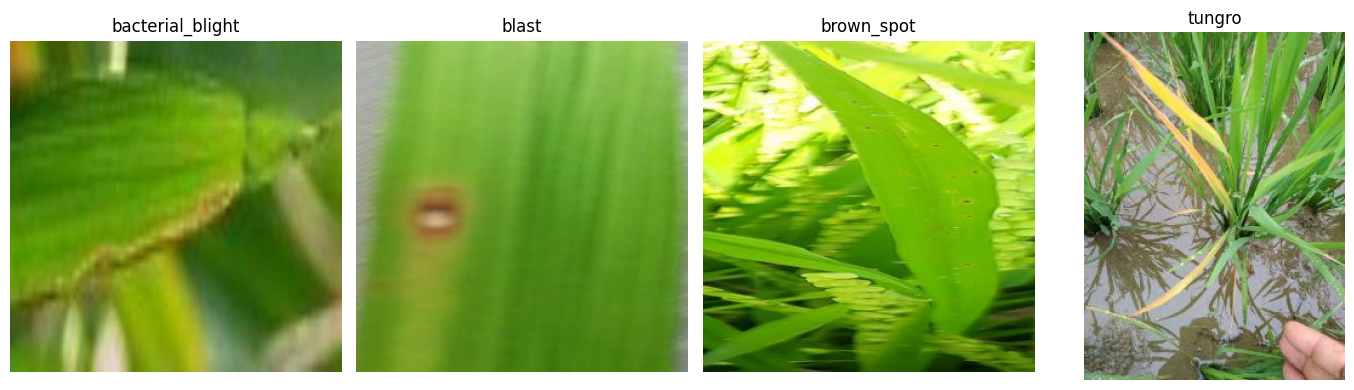

In [ ]:
split_path = RUN / 'split.csv'
if split_path.exists():
    old = pd.read_csv(split_path)
    assert set(old.sha256) == set(df.sha256), 'Audit changed: create a new experiment.'
    df = df.merge(old[['sha256','split']], on='sha256', validate='one_to_one')
else:
    assert df.groupby('label').group.nunique().min() >= 20, 'Too few groups for this split.'
    splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=SEED)
    df['split'] = ''
    for fold, (_, idx) in enumerate(splitter.split(df, df.target, df.group)):
        df.loc[idx, 'split'] = 'test' if fold < 3 else ('val' if fold < 6 else 'train')
    df.to_csv(split_path, index=False)
assert df.groupby('group').split.nunique().max() == 1
assert df.groupby('sha256').split.nunique().max() == 1
for split in ['train','val','test']:
    assert set(df[df.split == split].label) == set(CLASSES)
display(pd.crosstab(df.label, df.split))
train_df = df[df.split == 'train'].reset_index(drop=True)
val_df = df[df.split == 'val'].reset_index(drop=True)
test_df = df[df.split == 'test'].reset_index(drop=True)
fig, axes = plt.subplots(1,4,figsize=(14,4))
for ax, label in zip(axes, CLASSES):
    row = train_df[train_df.label == label].iloc[0]
    ax.imshow(read_rgb(row.path)); ax.set_title(label); ax.axis('off')
plt.tight_layout(); plt.show()
print('Review the examples and audit before confirming the mask cell.')


,min,median,max
label,,,
bacterial_blight,0.001644,0.093944,0.420644
blast,0.001778,0.037272,0.209733
brown_spot,0.000556,0.010906,0.091733
tungro,0.007726,0.036657,0.132056


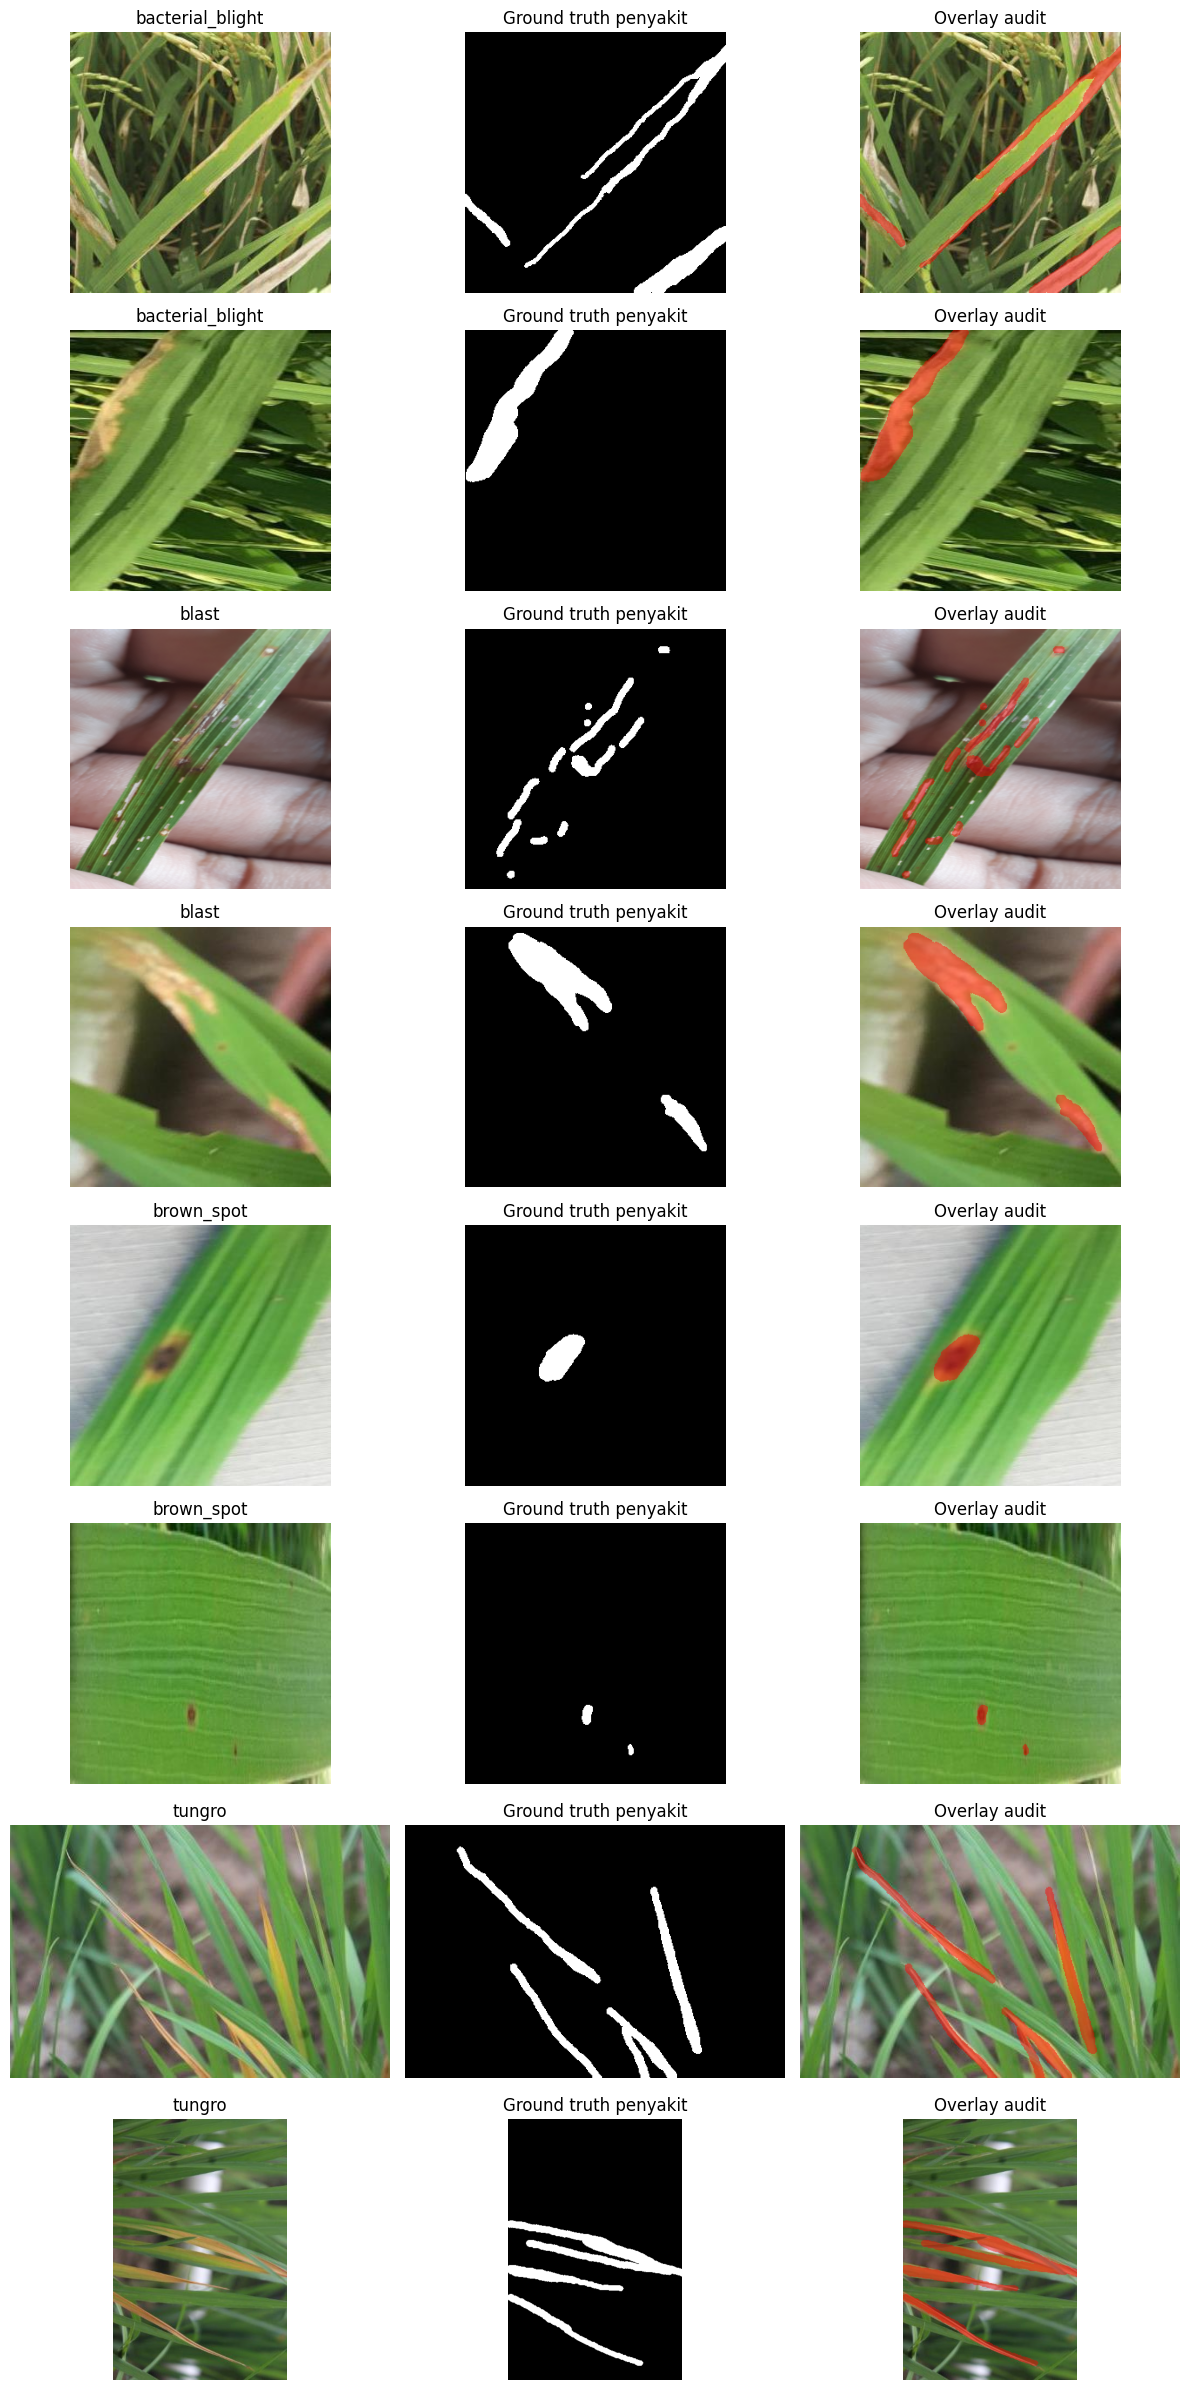

In [ ]:
if TRAIN_SEGMENTATION:
    mask_index = defaultdict(list)
    for p in (LOCAL / 'masks').rglob('*'):
        if p.suffix.lower() in EXTENSIONS and '__MACOSX' not in p.parts:
            mask_index[p.name].append(p)
    paired, issues = [], []
    for row in tqdm(df.itertuples(), total=len(df), desc='Image-mask pair audit'):
        candidates = mask_index[row.filename]
        if len(candidates) > 1:
            candidates = [p for p in candidates if folder_label(p) == row.label]
        if len(candidates) != 1:
            issues.append({'image':row.path,'error':f'{len(candidates)} pasangan'}); continue
        p = candidates[0]
        try:
            mask = read_rgb(p)
            arr = np.array(mask).astype(np.int16)
            assert mask.size == (row.width,row.height), 'Mask dimensions or orientation differ'
            assert np.mean(arr.max(2)-arr.min(2) > 15) < .01, 'Colored mask; review the encoding'
            binary = np.array(mask.convert('L')) >= 128
            if not MASK_WHITE_IS_LESION: binary = ~binary
            paired.append(dict(sha256=row.sha256, mask_path=str(p), mask_sha256=sha256(p),
                               coverage=float(binary.mean())))
        except Exception as e:
            issues.append({'image':row.path,'error':str(e)})
    pd.DataFrame(issues).to_csv(RUN / 'mask_issues.csv', index=False)
    assert not issues, 'Mask pairs need review. Check mask_issues.csv before segmentation training.'
    pairs = pd.DataFrame(paired)
    df = df.merge(pairs, on='sha256', validate='one_to_one')
    df.to_csv(RUN / 'paired_split.csv', index=False)
    print('Empty/full masks:', int(((df.coverage == 0) | (df.coverage == 1)).sum()))
    display(df.groupby('label').coverage.agg(['min','median','max']))
    examples = df[df.split == 'train'].groupby('label', group_keys=False).sample(2, random_state=SEED)
    fig, axes = plt.subplots(len(examples),3,figsize=(12,3*len(examples)))
    for axs, row in zip(axes, examples.itertuples()):
        im = np.array(read_rgb(row.path)); m = np.array(read_rgb(row.mask_path).convert('L')) >= 128
        if not MASK_WHITE_IS_LESION: m = ~m
        overlay = im.copy(); overlay[m] = (.55*im[m]+.45*np.array([255,0,0])).astype('uint8')
        for ax, picture, title in zip(axs,[im,m,overlay],[row.label,'Disease ground truth','Audit overlay']):
            ax.imshow(picture,cmap='gray'); ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()
    approved = RUN / 'mask_approved.json'
    if not approved.exists():
        answer = input('If the pairs, labels, and white regions are correct, type AGREE: ').strip()
        assert answer == 'AGREE', 'Stopped to prevent use of unverified masks.'
        approved.write_text(json.dumps({'dataset':dataset_identity,'white_is_lesion':MASK_WHITE_IS_LESION}))
else:
    print('Segmentation disabled. Classification and Grad-CAM++ remain available.')


In [ ]:
MEAN = [0.485,0.456,0.406]
STD = [0.229,0.224,0.225]
normalize = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
jitter = transforms.ColorJitter(brightness=.15,contrast=.15,saturation=.10)
def letterbox(im, size=IMAGE_SIZE, mask=False):
    ratio = min(size/im.width, size/im.height)
    w,h = max(1,round(im.width*ratio)),max(1,round(im.height*ratio))
    im = im.resize((w,h), Image.Resampling.NEAREST if mask else Image.Resampling.BILINEAR)
    canvas = Image.new('L' if mask else 'RGB', (size,size), 0 if mask else (124,116,104))
    left,top = (size-w)//2,(size-h)//2
    canvas.paste(im,(left,top))
    return canvas,(left,top,w,h)
def preprocess(im):
    square, box = letterbox(im)
    return normalize(square), square, box

class RiceDataset(Dataset):
    def __init__(self, frame, training=False, segmentation=False):
        self.frame=frame.reset_index(drop=True); self.training=training; self.segmentation=segmentation
    def __len__(self): return len(self.frame)
    def __getitem__(self,index):
        row = self.frame.iloc[index]
        im = read_rgb(row.path)
        mask = None
        if self.segmentation:
            a = np.array(read_rgb(row.mask_path).convert('L')) >= 128
            if not MASK_WHITE_IS_LESION: a = ~a
            mask = Image.fromarray(a.astype('uint8')*255)
        im,_ = letterbox(im)
        if mask is not None: mask,_ = letterbox(mask,mask=True)
        if self.training:
            if random.random() < .5:
                im = ImageOps.mirror(im)
                if mask is not None: mask = ImageOps.mirror(mask)
            if random.random() < .5:
                im = ImageOps.flip(im)
                if mask is not None: mask = ImageOps.flip(mask)
            angle = random.uniform(-15,15)
            im = im.rotate(angle,resample=Image.Resampling.BILINEAR,fillcolor=(124,116,104))
            if mask is not None: mask = mask.rotate(angle,resample=Image.Resampling.NEAREST,fillcolor=0)
            im = jitter(im)
        x = normalize(im)
        if mask is not None:
            return x, torch.from_numpy((np.array(mask)>127).astype('float32'))[None]
        return x, int(row.target)

def seed_worker(worker_id):
    seed = torch.initial_seed() % 2**32
    np.random.seed(seed); random.seed(seed)
def loader(frame, training=False, segmentation=False):
    return DataLoader(RiceDataset(frame,training,segmentation), batch_size=BATCH_SIZE,
                      shuffle=training, num_workers=NUM_WORKERS, pin_memory=True,
                      worker_init_fn=seed_worker, drop_last=False)


In [ ]:
def make_classifier(name, pretrained=True):
    factories = {
        'densenet121': (models.densenet121, models.DenseNet121_Weights.DEFAULT),
        'convnext_tiny': (models.convnext_tiny, models.ConvNeXt_Tiny_Weights.DEFAULT),
        'efficientnet_v2_s': (models.efficientnet_v2_s, models.EfficientNet_V2_S_Weights.DEFAULT)}
    factory, weights = factories[name]
    model = factory(weights=weights if pretrained else None)
    if name == 'densenet121':
        model.classifier = nn.Linear(model.classifier.in_features,len(CLASSES))
    else:
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features,len(CLASSES))
    return model
def make_segmenter(pretrained=True):
    return smp.UnetPlusPlus(encoder_name='resnet34', encoder_weights='imagenet' if pretrained else None,
                           in_channels=3,classes=1,activation=None)
def atomic_save(obj,path):
    tmp = path.with_suffix(path.suffix+'.tmp')
    torch.save(obj,tmp); os.replace(tmp,path)
def checkpoint_load(path):
    # Trusted checkpoints generated by this notebook, not uploaded arbitrary pickle files.
    return torch.load(path,map_location='cpu',weights_only=False)
def rng_state():
    return dict(python=random.getstate(),numpy=np.random.get_state(),torch=torch.get_rng_state(),
                cuda=torch.cuda.get_rng_state_all())
def restore_rng(state):
    random.setstate(state['python']); np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch']); torch.cuda.set_rng_state_all(state['cuda'])
def cpu_weights(model): return {k:v.detach().cpu() for k,v in model.state_dict().items()}

def segmentation_loss(logits,y):
    bce = F.binary_cross_entropy_with_logits(logits,y)
    p = logits.sigmoid()
    dice = (2*(p*y).sum((1,2,3))+1)/((p+y).sum((1,2,3))+1)
    return bce + (1-dice).mean()

def epoch_pass(model, data, optimizer=None, scaler=None, segmentation=False):
    training = optimizer is not None
    model.train(training)
    if training: optimizer.zero_grad(set_to_none=True)
    total_loss,n = 0.,0
    actual,predicted, dice_values = [],[],[]
    for step,(x,y) in enumerate(tqdm(data,leave=False,desc='Train' if training else 'Validation')):
        x,y = x.to(DEVICE,non_blocking=True),y.to(DEVICE,non_blocking=True)
        with torch.set_grad_enabled(training), torch.autocast(device_type='cuda',dtype=torch.float16):
            logits = model(x)
            loss = segmentation_loss(logits,y) if segmentation else F.cross_entropy(logits,y,label_smoothing=.05)
        if training:
            group_start = (step//ACCUMULATION)*ACCUMULATION
            group_size = min(ACCUMULATION,len(data)-group_start)
            scaler.scale(loss/group_size).backward()
            if (step+1)%ACCUMULATION == 0 or step+1 == len(data):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(),1.)
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item()*len(x); n += len(x)
        if segmentation:
            p = logits.detach().sigmoid() >= .5
            intersection = (p*y).sum((1,2,3)); denominator = p.sum((1,2,3))+y.sum((1,2,3))
            dice_values.extend(((2*intersection+1e-7)/(denominator+1e-7)).cpu().tolist())
        else:
            actual.extend(y.cpu().tolist()); predicted.extend(logits.detach().argmax(1).cpu().tolist())
    score = float(np.mean(dice_values)) if segmentation else f1_score(actual,predicted,average='macro',zero_division=0)
    return total_loss/n,score

def train_model(name, segmentation=False):
    folder = RUN / name; folder.mkdir(exist_ok=True)
    last_path,best_path = folder/'last.pt',folder/'best.pt'
    epochs = SEG_EPOCHS if segmentation else EPOCHS
    saved = checkpoint_load(last_path) if last_path.exists() else None
    if saved and (saved['epoch']+1 >= epochs or saved['bad_epochs'] >= PATIENCE):
        print(name,'already complete. Best validation:',saved['best_score']); return
    seed_all(SEED)
    model = (make_segmenter(saved is None) if segmentation else make_classifier(name,saved is None)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda')
    start,best_score,bad_epochs,history = 0,-1.,0,[]
    if saved:
        model.load_state_dict(saved['model']); optimizer.load_state_dict(saved['optimizer'])
        scheduler.load_state_dict(saved['scheduler']); scaler.load_state_dict(saved['scaler'])
        start=saved['epoch']+1; best_score=saved['best_score']; bad_epochs=saved['bad_epochs']; history=saved['history']
        restore_rng(saved['rng']); print('Resume',name,'epoch',start+1)
    frame = df if segmentation else pd.concat([train_df,val_df])
    train_loader = loader(frame[frame.split=='train'],True,segmentation)
    val_loader = loader(frame[frame.split=='val'],False,segmentation)
    for epoch in range(start,epochs):
        tic=time.time()
        train_loss,train_score = epoch_pass(model,train_loader,optimizer,scaler,segmentation)
        val_loss,val_score = epoch_pass(model,val_loader,segmentation=segmentation)
        scheduler.step()
        history.append(dict(epoch=epoch+1,train_loss=train_loss,val_loss=val_loss,
                            train_score=train_score,val_score=val_score,minutes=(time.time()-tic)/60))
        if val_score > best_score:
            best_score=val_score; bad_epochs=0
            atomic_save(dict(model=cpu_weights(model),name=name,score=best_score,epoch=epoch,
                             config=CONFIG),best_path)
        else: bad_epochs += 1
        atomic_save(dict(model=cpu_weights(model),optimizer=optimizer.state_dict(),
                         scheduler=scheduler.state_dict(),scaler=scaler.state_dict(),
                         rng=rng_state(),epoch=epoch,best_score=best_score,bad_epochs=bad_epochs,
                         history=history),last_path)
        pd.DataFrame(history).to_csv(folder/'history.csv',index=False)
        print(f'{name} {epoch+1}/{epochs} | val score {val_score:.4f} | best {best_score:.4f} | {history[-1]["minutes"]:.1f} minutes')
        if bad_epochs >= PATIENCE:
            print('Early stopping.'); break
    del model,optimizer,scaler,saved
    gc.collect(); torch.cuda.empty_cache()


In [ ]:
x,y = next(iter(loader(train_df)))
for name in CANDIDATES:
    m = make_classifier(name,False).to(DEVICE).eval()
    with torch.inference_mode(),torch.autocast(device_type='cuda',dtype=torch.float16):
        result=m(x.to(DEVICE))
    assert result.shape == (len(x),len(CLASSES)) and torch.isfinite(result).all()
    print(name,'OK',tuple(result.shape))
    del m,result; gc.collect(); torch.cuda.empty_cache()
if TRAIN_SEGMENTATION:
    sx,sy=next(iter(loader(df[df.split=='train'],segmentation=True)))
    m=make_segmenter(False).to(DEVICE).eval()
    with torch.inference_mode(): result=m(sx.to(DEVICE))
    assert result.shape == sy.shape and torch.isfinite(result).all()
    print('Segmentation OK',tuple(result.shape))
    del m,result,sx,sy; gc.collect(); torch.cuda.empty_cache()


densenet121 already complete. Best validation: 1.0
convnext_tiny already complete. Best validation: 1.0
efficientnet_v2_s already complete. Best validation: 1.0


,model,validation_macro_f1
0,densenet121,1.0
1,convnext_tiny,1.0
2,efficientnet_v2_s,1.0


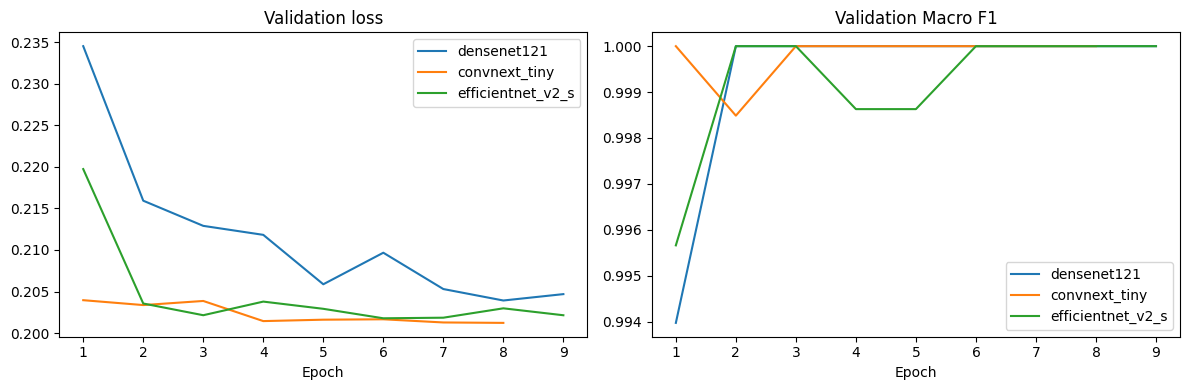

Selected classifier: densenet121


In [ ]:
for name in CANDIDATES:
    train_model(name)
leaderboard = pd.DataFrame([dict(model=name,validation_macro_f1=checkpoint_load(RUN/name/'best.pt')['score'])
                            for name in CANDIDATES]).sort_values('validation_macro_f1',ascending=False)
leaderboard.to_csv(RUN/'validation_leaderboard.csv',index=False)
display(leaderboard)
WINNER = leaderboard.iloc[0].model
classifier=make_classifier(WINNER,False).to(DEVICE)
classifier.load_state_dict(checkpoint_load(RUN/WINNER/'best.pt')['model']); classifier.eval()
fig,axes=plt.subplots(1,2,figsize=(12,4))
for name in CANDIDATES:
    h=pd.read_csv(RUN/name/'history.csv')
    axes[0].plot(h.epoch,h.val_loss,label=name)
    axes[1].plot(h.epoch,h.val_score,label=name)
axes[0].set_title('Validation loss'); axes[1].set_title('Validation Macro F1')
for ax in axes: ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout(); plt.savefig(RUN/'classification_learning_curves.png',dpi=160); plt.show()
print('Selected classifier:',WINNER)


In [ ]:
@torch.no_grad()
def collect_logits(model,frame):
    logits,labels=[],[]
    for x,y in tqdm(loader(frame),desc='Inference'):
        logits.append(model(x.to(DEVICE)).float().cpu()); labels.append(y)
    return torch.cat(logits),torch.cat(labels)
val_logits,val_y=collect_logits(classifier,val_df)
raw_correct = val_logits.argmax(1).eq(val_y)
if bool(raw_correct.all()):
    # With no validation errors, NLL tends to push T toward zero, producing
    # overconfident probabilities. Do not claim identifiable calibration.
    TEMPERATURE=1.0
    temperature_note='skipped: seluruh prediksi validation benar'
else:
    log_temperature=nn.Parameter(torch.zeros(()))
    optim_t=torch.optim.LBFGS([log_temperature],lr=.05,max_iter=100)
    def closure():
        optim_t.zero_grad()
        loss=F.cross_entropy(val_logits/log_temperature.exp().clamp(.05,20.),val_y)
        loss.backward(); return loss
    optim_t.step(closure)
    TEMPERATURE=float(log_temperature.detach().exp().clamp(.05,20.))
    temperature_note='optimized on validation NLL'
val_prob=(val_logits/TEMPERATURE).softmax(1).numpy()
confidence=val_prob.max(1); correct=val_prob.argmax(1)==val_y.numpy()
options=[]
for threshold in np.linspace(.25,.99,150):
    keep=confidence>=threshold
    if keep.sum()>=30 and correct[keep].mean()>=.95:
        options.append((int(keep.sum()),float(threshold)))
THRESHOLD=max(options)[1] if options else 1.01
calibration=dict(temperature=TEMPERATURE,threshold=THRESHOLD,
                 threshold_found=bool(options),selection='validation only',not_ood_detector=True,
                 temperature_note=temperature_note)
(RUN/'calibration.json').write_text(json.dumps(calibration,indent=2))
print(calibration)
if not options: print('Selective accuracy target not met; flag every result for review.')


{'temperature': 1.0, 'threshold': 0.845973154362416, 'threshold_found': True, 'selection': 'validation only', 'not_ood_detector': True, 'temperature_note': 'skipped: seluruh prediksi validation benar'}


,precision,recall,f1-score,support
Bacterial Blight,1.0,1.0,1.0,193.0
Blast,1.0,1.0,1.0,142.0
Brown Spot,1.0,1.0,1.0,185.0
Tungro,1.0,1.0,1.0,212.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,732.0
weighted avg,1.0,1.0,1.0,732.0


{'accuracy': 1.0, 'macro_f1': 1.0, 'coverage': 1.0, 'accuracy_accepted': 1.0}


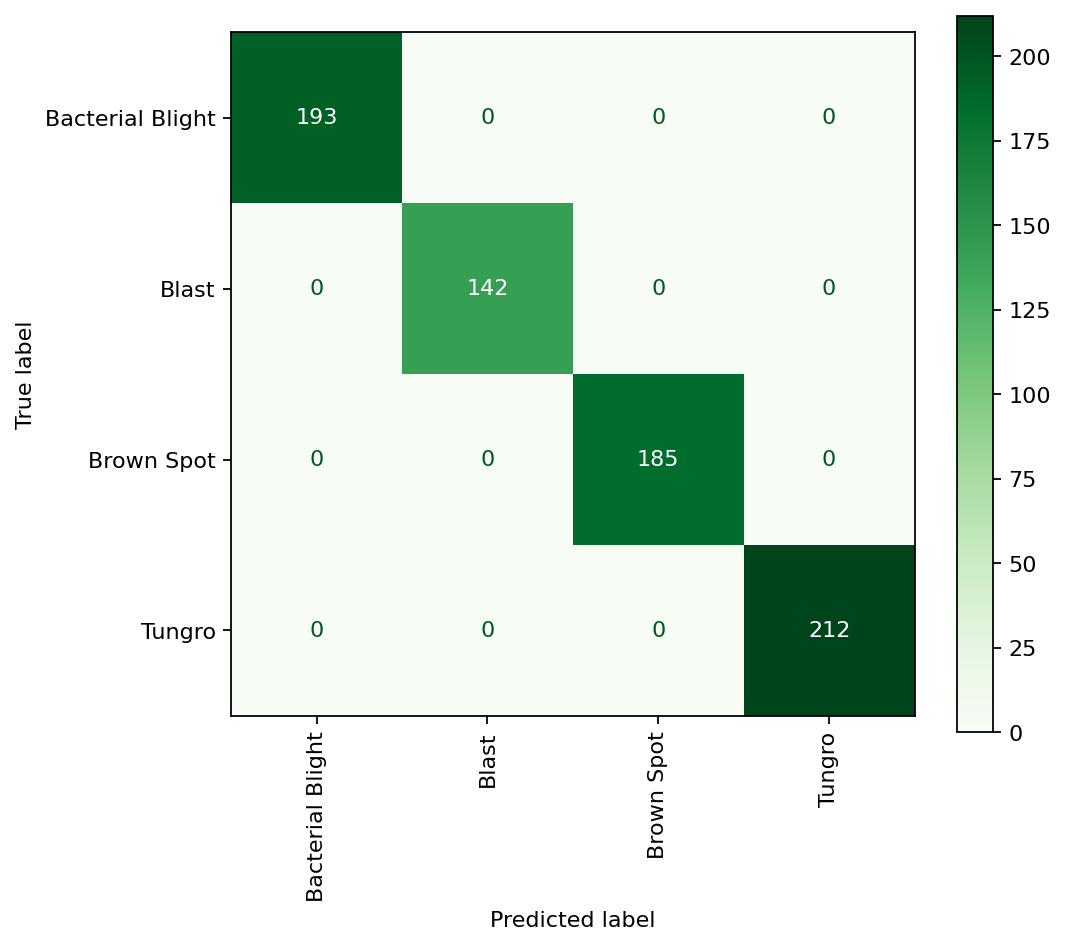

In [ ]:
test_cache=RUN/'test_predictions.npz'
if test_cache.exists():
    with np.load(test_cache) as cache:
        test_prob=cache['prob']; test_y=cache['y']
else:
    test_logits,test_labels=collect_logits(classifier,test_df)
    test_prob=(test_logits/TEMPERATURE).softmax(1).numpy(); test_y=test_labels.numpy()
    np.savez_compressed(test_cache,prob=test_prob,y=test_y)
test_pred=test_prob.argmax(1)
report=classification_report(test_y,test_pred,labels=range(4),target_names=LABELS,output_dict=True,zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RUN/'classification_test_report.csv')
accepted=test_prob.max(1)>=THRESHOLD
summary={'accuracy':accuracy_score(test_y,test_pred),
         'macro_f1':f1_score(test_y,test_pred,average='macro'),
         'coverage':float(accepted.mean()),
         'accuracy_accepted':float((test_y[accepted]==test_pred[accepted]).mean()) if accepted.any() else None}
(RUN/'classification_test_summary.json').write_text(json.dumps(summary,indent=2))
print(summary)
fig,ax=plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(test_y,test_pred,display_labels=LABELS,cmap='Greens',ax=ax,xticks_rotation=90)
plt.tight_layout(); plt.savefig(RUN/'confusion_matrix.png',dpi=160); plt.show()
predictions=test_df[['path','label']].copy()
predictions['prediction']=[CLASSES[i] for i in test_pred]
predictions['score']=test_prob.max(1)
predictions.to_csv(RUN/'test_predictions.csv',index=False)
errors=predictions[predictions.label!=predictions.prediction].sort_values('score',ascending=False).head(8)
if len(errors):
    fig,axes=plt.subplots(2,4,figsize=(16,8))
    for ax in axes.flat: ax.axis('off')
    for ax,row in zip(axes.flat,errors.itertuples()):
        ax.imshow(read_rgb(row.path)); ax.set_title(f'{row.label} → {row.prediction}\n{row.score:.1%}',fontsize=9)
    plt.tight_layout(); plt.savefig(RUN/'misclassified_examples.png',dpi=160); plt.show()


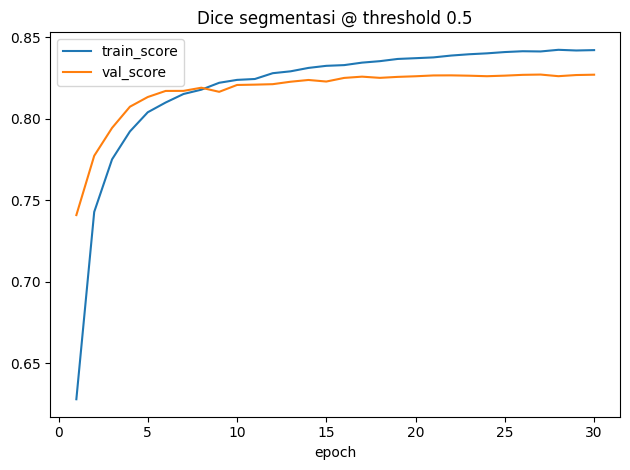

In [ ]:
classifier=classifier.cpu(); gc.collect(); torch.cuda.empty_cache()
segmenter=None
if TRAIN_SEGMENTATION:
    train_model('unetplusplus_resnet34',segmentation=True)
    segmenter=make_segmenter(False).to(DEVICE)
    segmenter.load_state_dict(checkpoint_load(RUN/'unetplusplus_resnet34/best.pt')['model'])
    segmenter.eval()
    h=pd.read_csv(RUN/'unetplusplus_resnet34/history.csv')
    h.plot(x='epoch',y=['train_score','val_score'],title='Segmentation Dice @ threshold 0.5')
    plt.tight_layout(); plt.savefig(RUN/'segmentation_learning_curves.png',dpi=160); plt.show()


In [ ]:
@torch.inference_mode()
def segmentation_scores(frame,thresholds):
    results=[]
    for row in tqdm(frame.itertuples(),total=len(frame),desc='Mask evaluation'):
        im=read_rgb(row.path)
        x,_,box=preprocess(im)
        prob=segmenter(x[None].to(DEVICE)).sigmoid()[0,0].cpu().numpy()
        m=np.array(read_rgb(row.mask_path).convert('L'))>=128
        if not MASK_WHITE_IS_LESION: m=~m
        target,_=letterbox(Image.fromarray(m.astype('uint8')*255),mask=True)
        left,top,w,h=box
        prob=prob[top:top+h,left:left+w]
        target=np.array(target)[top:top+h,left:left+w]>127
        for threshold in thresholds:
            pred=prob>=threshold; inter=np.logical_and(pred,target).sum()
            union=np.logical_or(pred,target).sum(); total=pred.sum()+target.sum()
            results.append(dict(path=row.path,label=row.label,threshold=float(threshold),
                                dice=float(2*inter/total) if total else 1.,
                                iou=float(inter/union) if union else 1.,target_empty=not target.any()))
    return pd.DataFrame(results)
SEG_THRESHOLD=.5
if TRAIN_SEGMENTATION:
    seg_val_path=RUN/'segmentation_validation.csv'
    if seg_val_path.exists(): seg_val=pd.read_csv(seg_val_path)
    else:
        seg_val=segmentation_scores(df[df.split=='val'],np.arange(.2,.81,.05))
        seg_val.to_csv(seg_val_path,index=False)
    by_threshold=seg_val.groupby('threshold').dice.mean()
    SEG_THRESHOLD=float(by_threshold.idxmax())
    seg_test_path=RUN/'segmentation_test.csv'
    if seg_test_path.exists(): seg_test=pd.read_csv(seg_test_path)
    else:
        seg_test=segmentation_scores(df[df.split=='test'],[SEG_THRESHOLD])
        seg_test.to_csv(seg_test_path,index=False)
    display(seg_test.groupby('label')[['dice','iou']].mean())
    print('Threshold validation:',SEG_THRESHOLD)
    print('Test mean:',seg_test[['dice','iou']].mean().to_dict())
    segmenter=segmenter.cpu(); torch.cuda.empty_cache()


,dice,iou
label,,
bacterial_blight,0.855563,0.753300
blast,0.801743,0.682535
brown_spot,0.815692,0.698814
tungro,0.789812,0.662569


Threshold validation: 0.39999999999999997
Test mean: {'dice': 0.8160031076946513, 'iou': 0.6995245555571037}


In [ ]:
EXPORT=RUN/'export'; EXPORT.mkdir(exist_ok=True)
classifier=classifier.cpu().eval()
atomic_save(cpu_weights(classifier),EXPORT/'classifier.pt')
if segmenter is not None:
    atomic_save(cpu_weights(segmenter),EXPORT/'segmenter.pt')
metadata=dict(architecture=WINNER,classes=CLASSES,labels=LABELS,image_size=IMAGE_SIZE,
              mean=MEAN,std=STD,resize='letterbox_bilinear',padding_rgb=[124,116,104],
              temperature=TEMPERATURE,confidence_threshold=THRESHOLD,
              segmentation='UnetPlusPlus/resnet34' if segmenter is not None else None,
              segmentation_threshold=SEG_THRESHOLD,segmentation_normalization='imagenet',
              unknown_detector=False,healthy_class=False,
              torch=torch.__version__,torchvision=torchvision.__version__,smp=smp.__version__,
              sources=['https://doi.org/10.17632/fwcj7stb8r.2','https://doi.org/10.17632/92jc6w6mcy.1'],
              license='Dataset CC BY 4.0; preserve attribution. Check pretrained-weight terms.',
              test_summary=summary,config=CONFIG)
(EXPORT/'metadata.json').write_text(json.dumps(metadata,indent=2))
shutil.copy2(RUN/'requirements_observed.txt',EXPORT/'requirements_observed.txt')
# Reload-equivalence test on a validation image.
reloaded=make_classifier(WINNER,False).eval()
reloaded.load_state_dict(torch.load(EXPORT/'classifier.pt',map_location='cpu',weights_only=True))
sample=preprocess(read_rgb(val_df.iloc[0].path))[0][None]
with torch.inference_mode():
    torch.testing.assert_close(classifier(sample),reloaded(sample),rtol=1e-5,atol=1e-6)
del reloaded
hashes={p.name:sha256(p) for p in EXPORT.iterdir() if p.is_file() and p.name!='checksums.json'}
(EXPORT/'checksums.json').write_text(json.dumps(hashes,indent=2))
bundle_path=Path(shutil.make_archive(str(RUN/'riceleaf_bundle'),'zip',EXPORT))
print('Bundle:',bundle_path)
print('Classifier predictions match before and after reload within numerical tolerance.')


,kelas,skor
1,Blast,0.810789
3,Tungro,0.180537
2,Brown Spot,0.007393
0,Bacterial Blight,0.001280


Predicted mask coverage of the image: 11.23% (not the percentage of diseased leaf tissue).


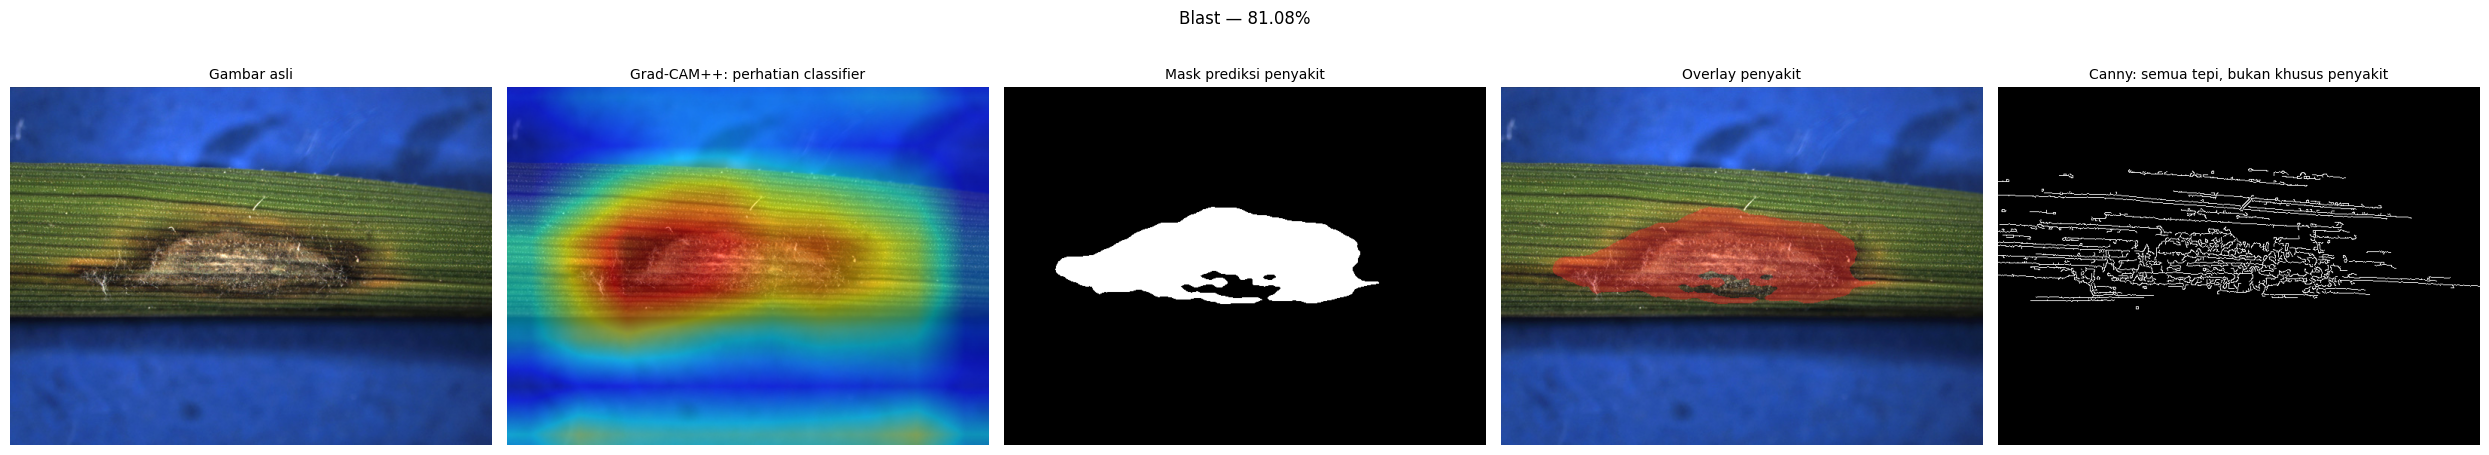

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
from google.colab import files

def predict_visualize(path):
    im=read_rgb(path)
    x,square,box=preprocess(im)
    classifier.to(DEVICE).eval()
    with torch.inference_mode():
        logits=classifier(x[None].to(DEVICE))
        prob=(logits/TEMPERATURE).softmax(1)[0].cpu().numpy()
    prediction=int(prob.argmax()); confidence=float(prob.max())
    status='Review required; low-confidence prediction' if confidence<THRESHOLD else 'Model prediction, not a confirmed diagnosis'
    print('Prediction:',LABELS[prediction], '| Score:',f'{confidence:.2%}', '|',status)
    display(pd.DataFrame({'class':LABELS,'score':prob}).sort_values('score',ascending=False))
    target_layer=classifier.features[-1]
    with GradCAMPlusPlus(model=classifier,target_layers=[target_layer]) as cam:
        heat=cam(input_tensor=x[None].to(DEVICE),targets=[ClassifierOutputTarget(prediction)])[0]
    left,top,w,h=box
    heat=heat[top:top+h,left:left+w]
    heat=cv2.resize(heat,im.size)
    original=np.array(im)
    cam_image=show_cam_on_image(original.astype('float32')/255,heat,use_rgb=True)
    pictures=[original,cam_image]
    titles=['Original image','Grad-CAM++: classifier attention']
    classifier.cpu(); torch.cuda.empty_cache()
    if segmenter is not None:
        segmenter.to(DEVICE).eval()
        with torch.inference_mode():
            mask_prob=segmenter(x[None].to(DEVICE)).sigmoid()[0,0].cpu().numpy()
        mask_prob=cv2.resize(mask_prob[top:top+h,left:left+w],im.size)
        mask=mask_prob>=SEG_THRESHOLD
        overlay=original.copy()
        overlay[mask]=(.6*original[mask]+.4*np.array([255,40,40])).astype('uint8')
        pictures.extend([mask,overlay]); titles.extend(['Predicted disease mask','Disease overlay'])
        print(f'Predicted mask coverage of the image: {mask.mean():.2%} (not the percentage of diseased leaf tissue).')
        segmenter.cpu(); torch.cuda.empty_cache()
    gray=cv2.cvtColor(original,cv2.COLOR_RGB2GRAY)
    edges=cv2.Canny(cv2.GaussianBlur(gray,(5,5),0),50,150)
    pictures.append(edges); titles.append('Canny: all image edges')
    fig,axes=plt.subplots(1,len(pictures),figsize=(5*len(pictures),5))
    for ax,picture,title in zip(axes,pictures,titles):
        ax.imshow(picture,cmap='gray'); ax.set_title(title,fontsize=10); ax.axis('off')
    plt.suptitle(f'{LABELS[prediction]} — {confidence:.2%}'); plt.tight_layout(); plt.show()
    return prob

uploaded=files.upload()
assert len(uploaded)==1,'Upload exactly one photo.'
uploaded_name=next(iter(uploaded))
# Use actual uploaded bytes; avoid accidentally reading an older same-name Colab file.
import io
with Image.open(io.BytesIO(uploaded[uploaded_name])) as uploaded_image:
    probe=ImageOps.exif_transpose(uploaded_image).convert('RGB')
    probe.save('/content/riceleaf_current_upload.png')
uploaded_prob=predict_visualize('/content/riceleaf_current_upload.png')
